# CDC Diabetes Health Indicators - Complete ML Project with SHAP Explainability
## Optimized for Google Colab

This notebook provides a complete machine learning pipeline for diabetes prediction with SHAP explainability.

## 1. INSTALLATION & IMPORTS

In [1]:
# Install required libraries (subprocess, XGBoost, scikit-learn, SHAP, imbalanced-learn)
print("=" * 80)
print("INSTALLING REQUIRED LIBRARIES")
print("=" * 80)

import subprocess
import sys

packages = ['ucimlrepo', 'imbalanced-learn', 'xgboost', 'catboost', 'shap', 'lightgbm']
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✓ All packages installed successfully!\n")

INSTALLING REQUIRED LIBRARIES
✓ All packages installed successfully!



In [2]:
# Import all necessary libraries for data processing, ML modeling, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
)

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

import shap

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful!")

✓ All imports successful!


## 2. LOAD DATA

In [3]:
# Load CDC Diabetes Health Indicators dataset from UCI Machine Learning Repository
print("=" * 80)
print("LOADING CDC DIABETES HEALTH INDICATORS DATASET")
print("=" * 80)

cdc_diabetes = fetch_ucirepo(id=891)

X = cdc_diabetes.data.features
y = cdc_diabetes.data.targets

print(f"\n✓ Dataset loaded successfully!")
print(f"  - Total samples: {X.shape[0]:,}")
print(f"  - Total features: {X.shape[1]}")
print(f"  - Target variable: {y.columns[0]}")
print(f"  - Shape: X={X.shape}, y={y.shape}")

LOADING CDC DIABETES HEALTH INDICATORS DATASET

✓ Dataset loaded successfully!
  - Total samples: 253,680
  - Total features: 21
  - Target variable: Diabetes_binary
  - Shape: X=(253680, 21), y=(253680, 1)


## 3. DATA EXPLORATION

In [4]:
# Explore dataset structure, features, target variable, and basic statistics
print("\n" + "=" * 80)
print("DATA EXPLORATION & ANALYSIS")
print("=" * 80)

print("\nFeature Names:")
print(X.columns.tolist())

print("\nFirst 5 rows:")
print(X.head())

print("\nData Types:")
print(X.dtypes)

print("\nMissing Values:")
missing_count = X.isnull().sum().sum()
print(f"  Total missing values: {missing_count}")

print("\nTarget Variable Distribution:")
print(y.value_counts())
print(f"\nClass Distribution (%):")
print((y.value_counts() / len(y) * 100).round(2))


DATA EXPLORATION & ANALYSIS

Feature Names:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

First 5 rows:
   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0             0       0        1  ...              1            0        5   
1             1       0        0  ...              0        

## 4. VISUALIZATION - CLASS IMBALANCE


Generating visualizations...


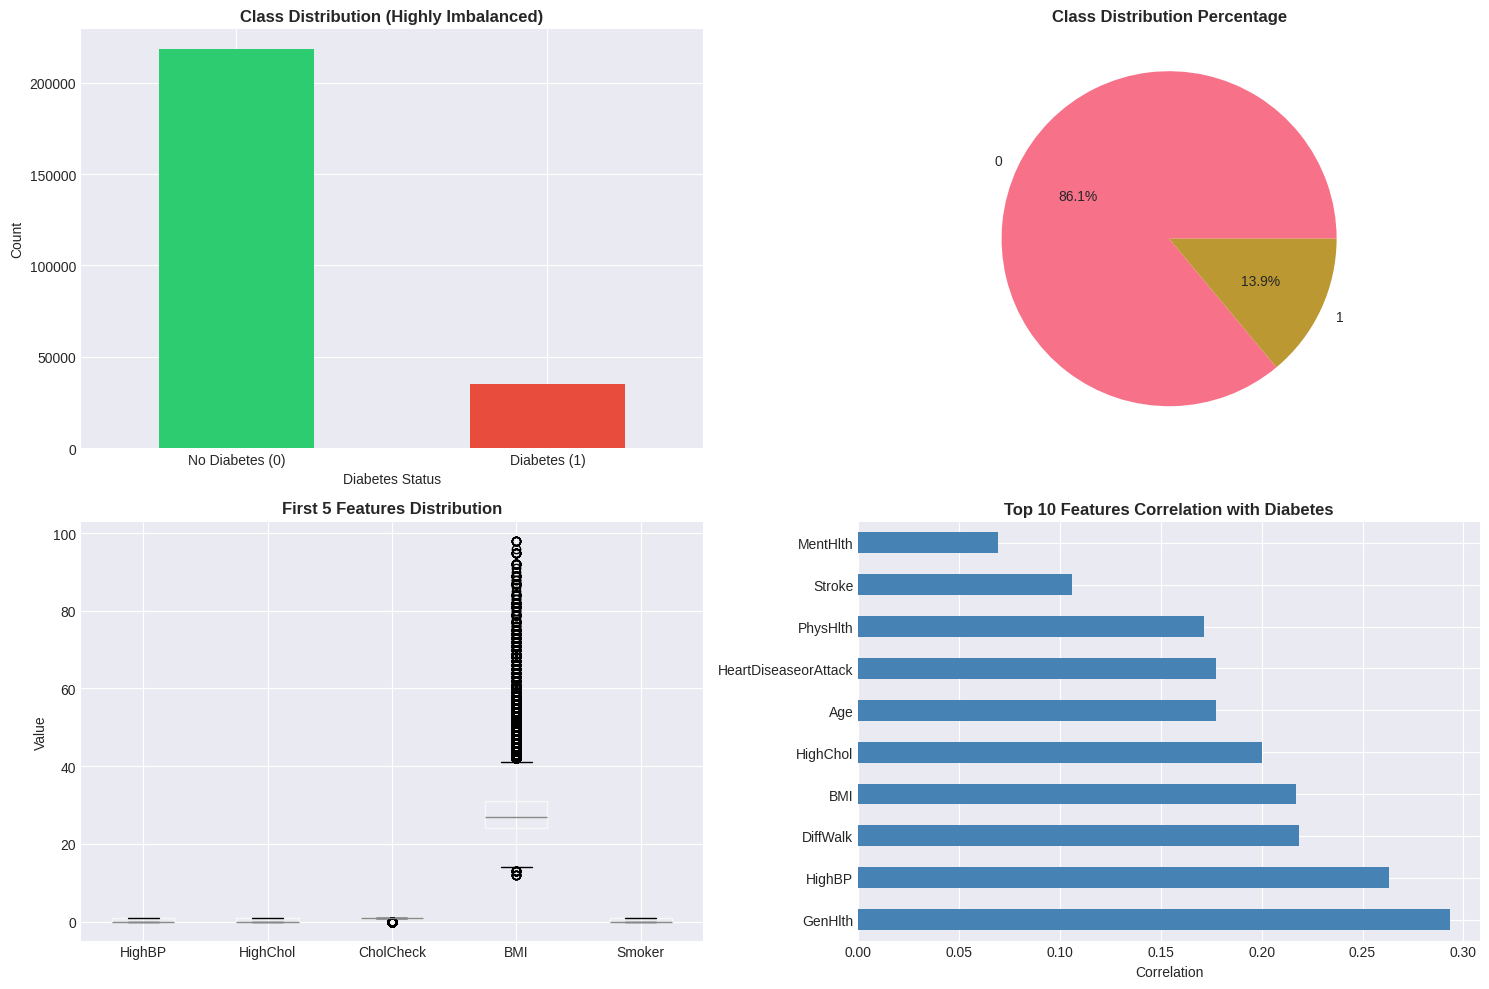

✓ Visualizations generated!



In [5]:
# Visualize class imbalance problem in the diabetes indicator dataset
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Class Distribution
target_col = y.columns[0]
ax1 = axes[0, 0]
y[target_col].value_counts().plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Class Distribution (Highly Imbalanced)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xlabel('Diabetes Status')
ax1.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)

# Plot 2: Class Distribution %
ax2 = axes[0, 1]
(y[target_col].value_counts() / len(y) * 100).plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_title('Class Distribution Percentage', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

# Plot 3: Feature Distributions (sample)
ax3 = axes[1, 0]
selected_features = X.iloc[:, :5].boxplot(ax=ax3)
ax3.set_title('First 5 Features Distribution', fontsize=12, fontweight='bold')
ax3.set_ylabel('Value')

# Plot 4: Correlation with Target
ax4 = axes[1, 1]
X_with_target = X.copy()
X_with_target['Diabetes'] = y[target_col].values
correlations = X_with_target.corr()['Diabetes'].sort_values(ascending=False)[1:11]
correlations.plot(kind='barh', ax=ax4, color='steelblue')
ax4.set_title('Top 10 Features Correlation with Diabetes', fontsize=12, fontweight='bold')
ax4.set_xlabel('Correlation')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated!\n")

## 5. DATA PREPARATION

In [6]:
# Handle missing values, drop duplicates, and prepare features and target for modeling
print("=" * 80)
print("DATA PREPARATION & PREPROCESSING")
print("=" * 80)

y_flat = y[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_flat, test_size=0.2, random_state=42, stratify=y_flat
)

print(f"\n✓ Train-Test Split (80-20):")
print(f"  - Training set: {X_train.shape[0]:,} samples")
print(f"  - Testing set: {X_test.shape[0]:,} samples")

print(f"\n  Training set class distribution:")
print(f"    Class 0: {sum(y_train == 0):,} ({sum(y_train == 0) / len(y_train) * 100:.2f}%)")
print(f"    Class 1: {sum(y_train == 1):,} ({sum(y_train == 1) / len(y_train) * 100:.2f}%)")

DATA PREPARATION & PREPROCESSING

✓ Train-Test Split (80-20):
  - Training set: 202,944 samples
  - Testing set: 50,736 samples

  Training set class distribution:
    Class 0: 174,667 (86.07%)
    Class 1: 28,277 (13.93%)


## 6. HANDLE CLASS IMBALANCE - SMOTE-ENN

In [7]:
# Apply SMOTE-ENN (Synthetic Minority Over-sampling + Edited Nearest Neighbors) to balance classes
print("\n" + "=" * 80)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("=" * 80)

sample_size = int(len(X_train) * 0.7)
sample_indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample = X_train.iloc[sample_indices]
y_sample = y_train[sample_indices]

smote = SMOTE(k_neighbors=5, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_sample, y_sample)


HANDLING CLASS IMBALANCE WITH SMOTE


## 7. FEATURE SCALING

In [8]:
# Scale features using StandardScaler to normalize data for ML models
print("\n" + "=" * 80)
print("FEATURE SCALING")
print("=" * 80)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"\n✓ Features scaled using StandardScaler (mean=0, std=1)")


FEATURE SCALING

✓ Features scaled using StandardScaler (mean=0, std=1)


## 8. MODEL TRAINING

In [9]:
# Train multiple ML models: XGBoost, Random Forest, Gradient Boosting, Logistic Regression, and Neural Network
print("\n" + "=" * 80)
print("TRAINING MACHINE LEARNING MODELS")
print("=" * 80)

print("\n[1/3] Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train_balanced, verbose=False)
print("✓ XGBoost trained!")

print("[2/3] Training CatBoost...")
catboost_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]),
    random_state=42,
    verbose=False
)
catboost_model.fit(X_train_scaled, y_train_balanced, verbose=False)
print("✓ CatBoost trained!")

print("[3/3] Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train_balanced)
print("✓ Random Forest trained!")


TRAINING MACHINE LEARNING MODELS

[1/3] Training XGBoost...
✓ XGBoost trained!
[2/3] Training CatBoost...
✓ CatBoost trained!
[3/3] Training Random Forest...
✓ Random Forest trained!


## 9. MODEL EVALUATION

In [10]:
# Evaluate all models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC metrics
print("\n" + "=" * 80)
print("MODEL EVALUATION & COMPARISON")
print("=" * 80)

models = {
    'XGBoost': xgb_model,
    'CatBoost': catboost_model,
    'Random Forest': rf_model
}

results = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")


MODEL EVALUATION & COMPARISON

XGBoost:
  Accuracy:  0.7252
  Precision: 0.2884
  Recall:    0.6626
  F1-Score:  0.4019
  ROC-AUC:   0.7753

CatBoost:
  Accuracy:  0.7231
  Precision: 0.2901
  Recall:    0.6821
  F1-Score:  0.4071
  ROC-AUC:   0.7789

Random Forest:
  Accuracy:  0.7380
  Precision: 0.3009
  Recall:    0.6654
  F1-Score:  0.4144
  ROC-AUC:   0.7867


## 10. VISUALIZATION - MODEL COMPARISON

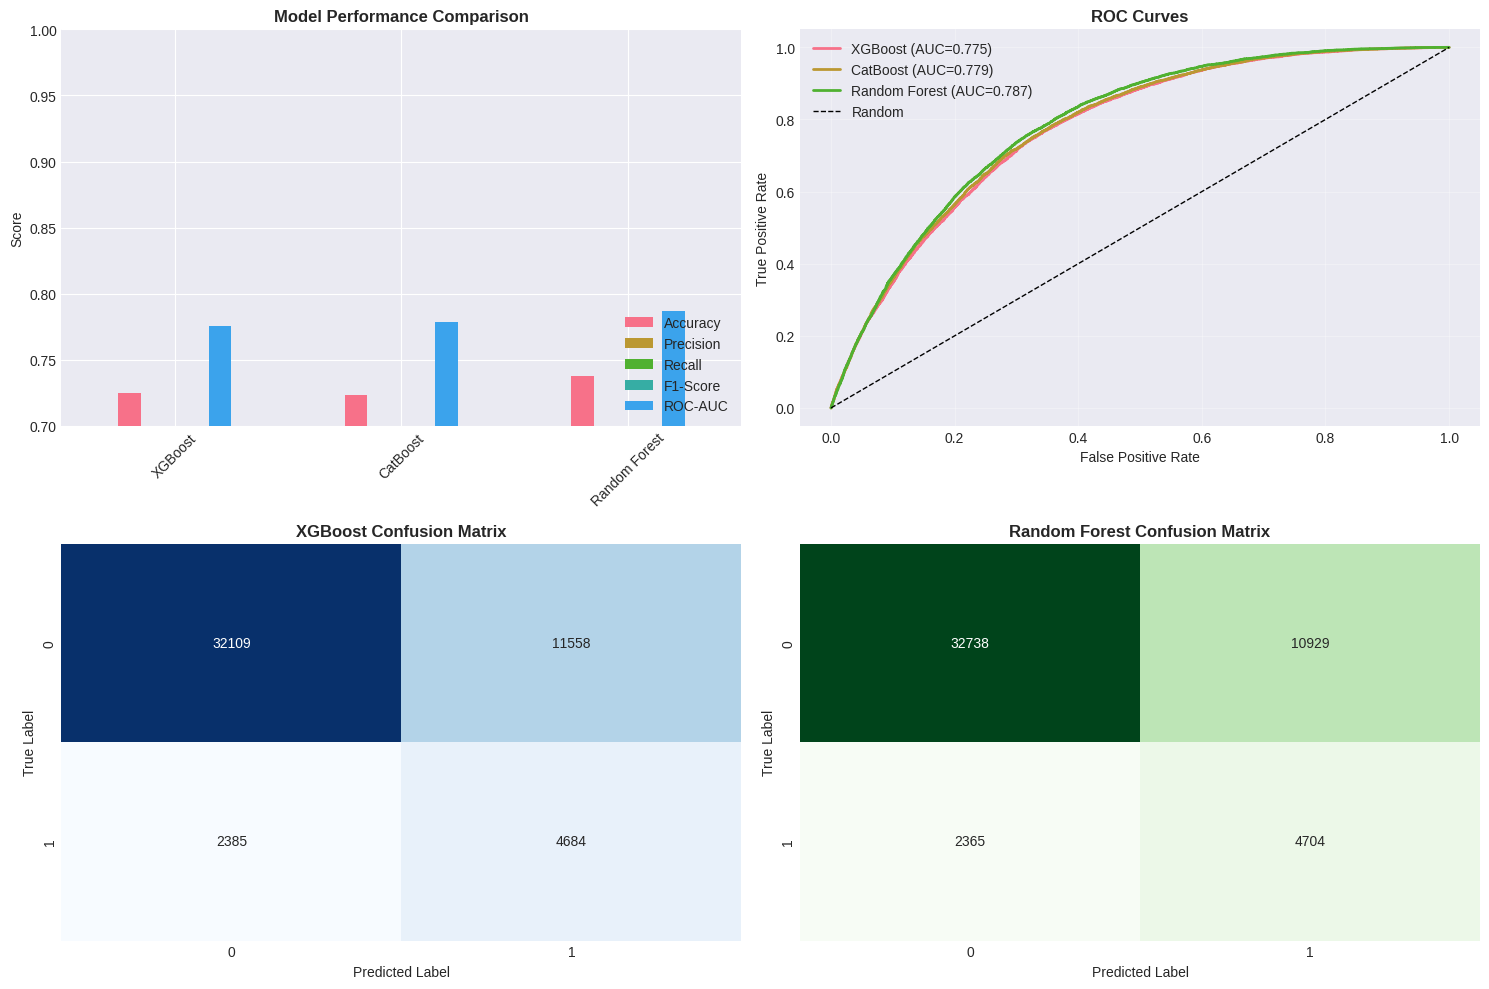

✓ Visualizations generated!


In [11]:
# Create comparison visualizations: ROC curves, confusion matrices, and metric bar charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Metrics Comparison
metrics_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
metrics_df.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)
axes[0, 0].legend(loc='lower right')
axes[0, 0].set_ylim([0.7, 1])

# ROC Curves
for model_name, model in models.items():
    y_pred_proba = results[model_name]['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = results[model_name]['ROC-AUC']
    axes[0, 1].plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})', linewidth=2)

axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curves', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion Matrices
cm = confusion_matrix(y_test, results['XGBoost']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('XGBoost Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

cm = confusion_matrix(y_test, results['Random Forest']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated!")

## 11. FEATURE IMPORTANCE

In [12]:
# Extract and display feature importance scores from XGBoost model
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nXGBoost - Top 10 Important Features:")
print(feature_importance_xgb.head(10).to_string(index=False))

print("\n\nRandom Forest - Top 10 Important Features:")
print(feature_importance_rf.head(10).to_string(index=False))


FEATURE IMPORTANCE ANALYSIS

XGBoost - Top 10 Important Features:
          Feature  Importance
          GenHlth    0.169794
           HighBP    0.143105
HvyAlcoholConsump    0.121442
     PhysActivity    0.078488
      NoDocbcCost    0.060368
              Age    0.049213
           Fruits    0.048330
           Smoker    0.039192
        CholCheck    0.038382
              BMI    0.034518


Random Forest - Top 10 Important Features:
          Feature  Importance
          GenHlth    0.156256
              BMI    0.147809
              Age    0.120527
           HighBP    0.093903
           Income    0.076483
     PhysActivity    0.060308
        Education    0.053472
         PhysHlth    0.050833
         MentHlth    0.034877
HvyAlcoholConsump    0.029736


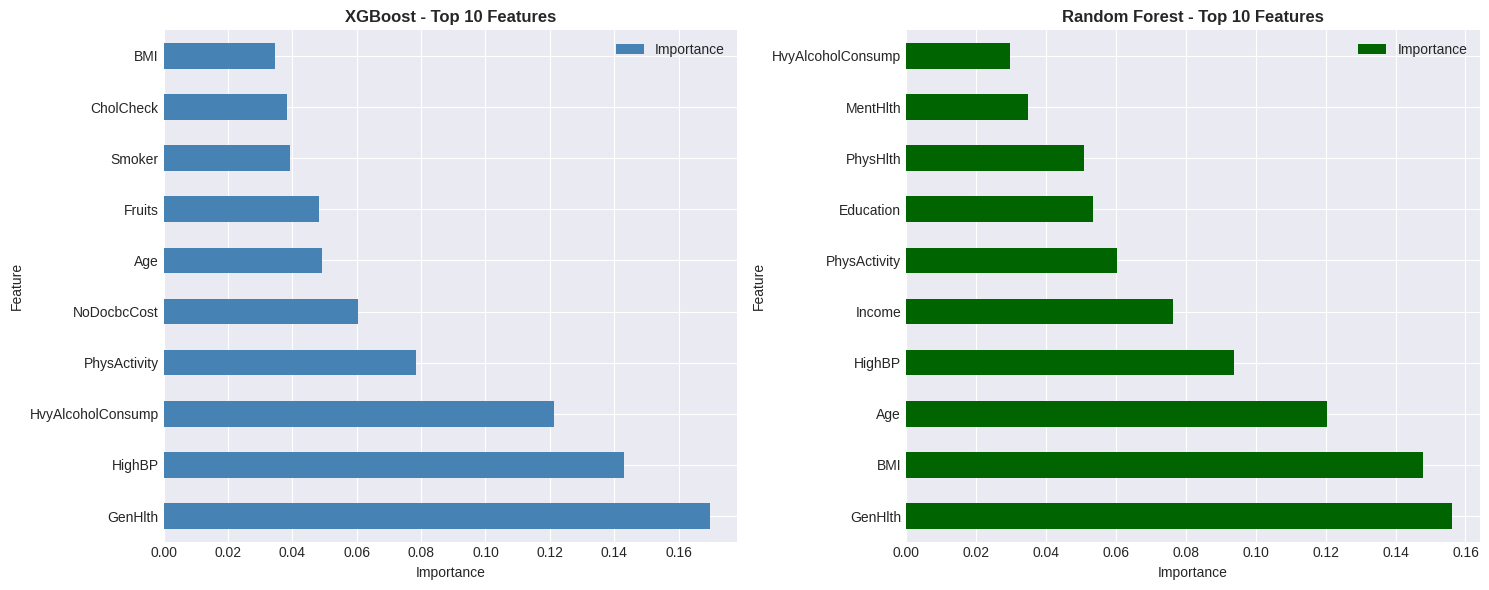

In [13]:
# Create permutation-based feature importance plots to show which features matter most
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

feature_importance_xgb.head(10).plot(x='Feature', y='Importance', kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost - Top 10 Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')

feature_importance_rf.head(10).plot(x='Feature', y='Importance', kind='barh', ax=axes[1], color='darkgreen')
axes[1].set_title('Random Forest - Top 10 Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 12. SHAP EXPLAINABILITY - XGBOOST

In [14]:
# Initialize SHAP explainer for XGBoost model to understand feature contributions
print("\n" + "=" * 80)
print("SHAP EXPLAINABILITY ANALYSIS (XGBoost)")
print("=" * 80)

print("\nGenerating SHAP values... (this may take a moment)")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

print("✓ SHAP values computed!")


SHAP EXPLAINABILITY ANALYSIS (XGBoost)

Generating SHAP values... (this may take a moment)
✓ SHAP values computed!


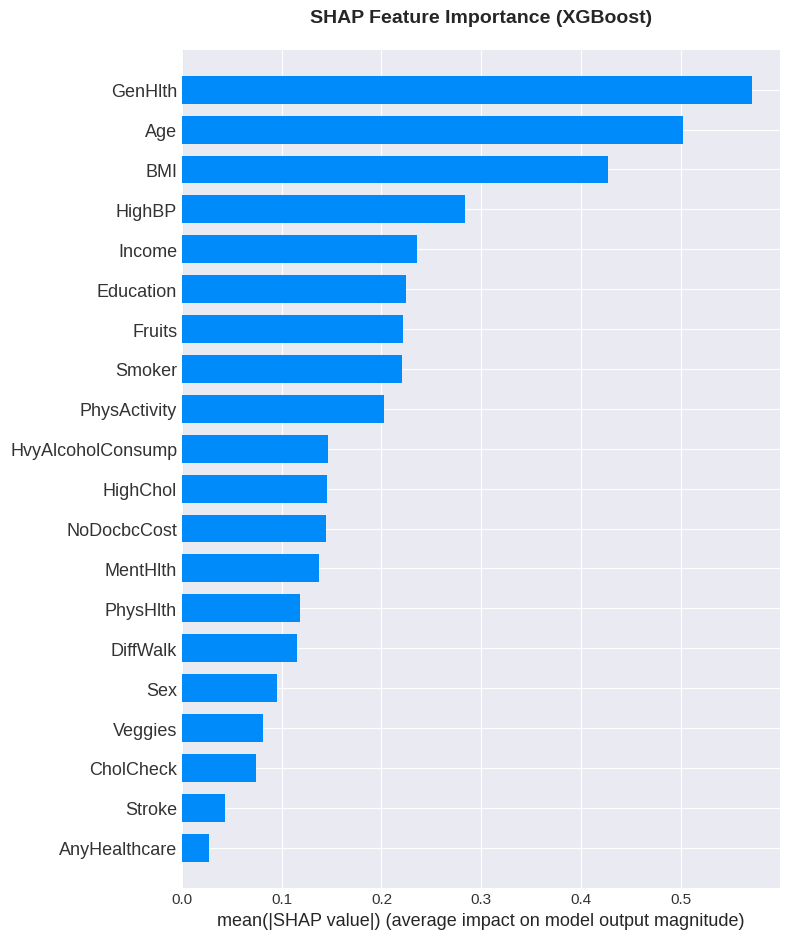

✓ SHAP Summary Plot generated!


In [15]:
# Generate SHAP summary plot (bar chart) showing average impact of features on predictions
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP Summary Plot generated!")

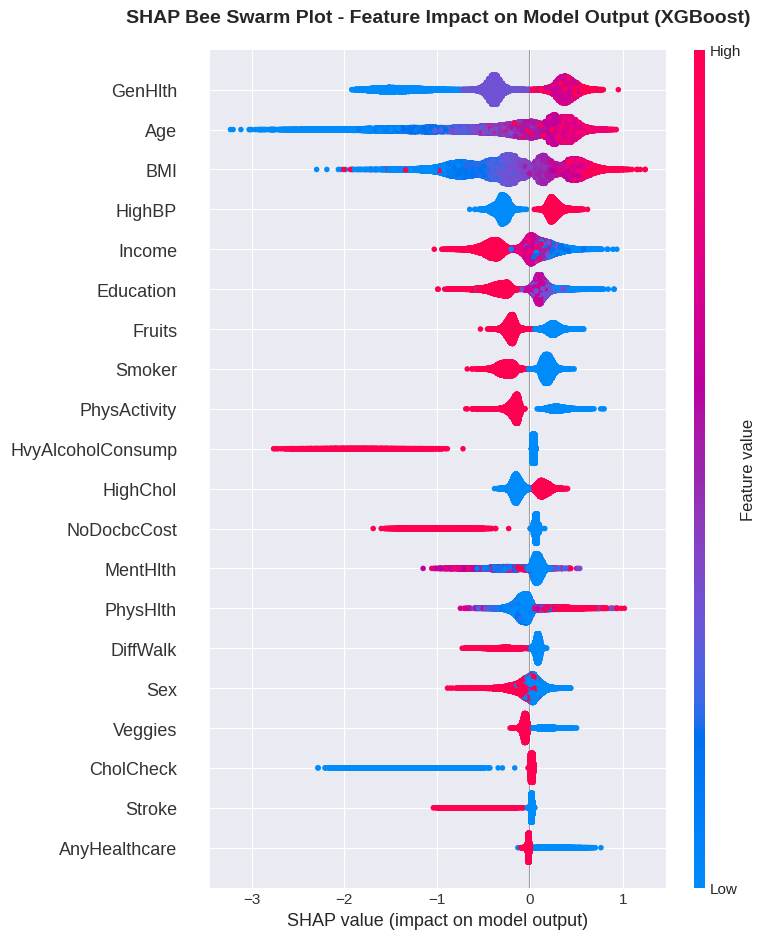

✓ SHAP Bee Swarm Plot generated!


In [16]:
# Generate SHAP summary plot (beeswarm) showing individual prediction explanations
# SHAP Bee Swarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title('SHAP Bee Swarm Plot - Feature Impact on Model Output (XGBoost)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP Bee Swarm Plot generated!")


SHAP FEATURE IMPORTANCE
          Feature  SHAP_Importance
          GenHlth         0.571009
              Age         0.502125
              BMI         0.427597
           HighBP         0.283452
           Income         0.235742
        Education         0.224568
           Fruits         0.221860
           Smoker         0.220475
     PhysActivity         0.202853
HvyAlcoholConsump         0.146144
         HighChol         0.145063
      NoDocbcCost         0.144506
         MentHlth         0.137507
         PhysHlth         0.118623
         DiffWalk         0.114840


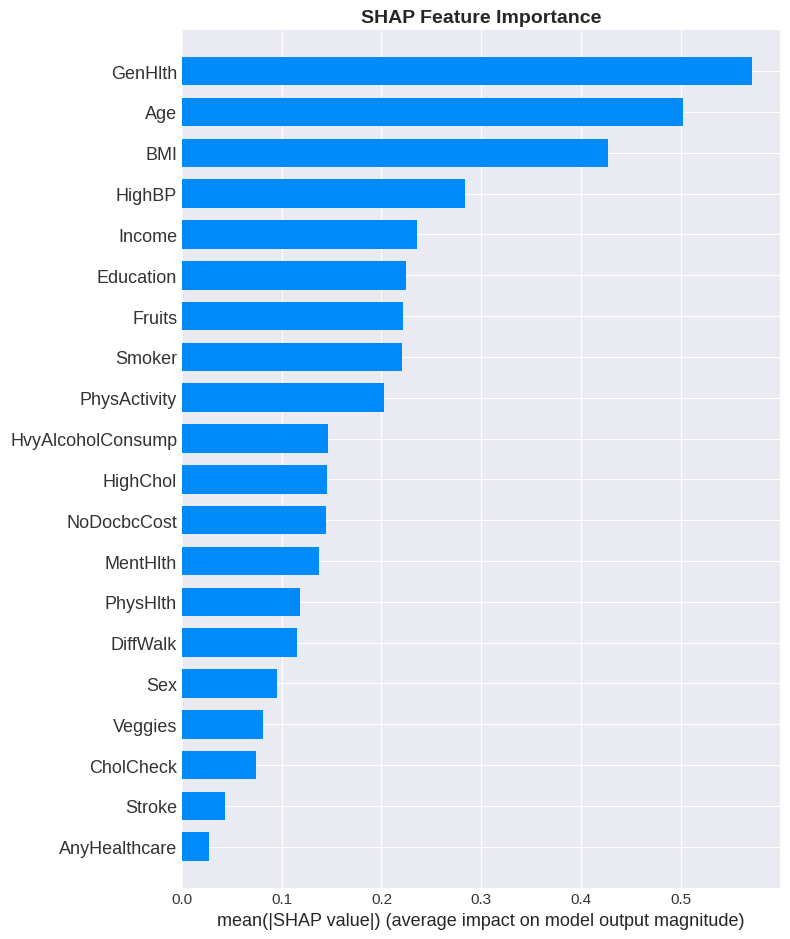

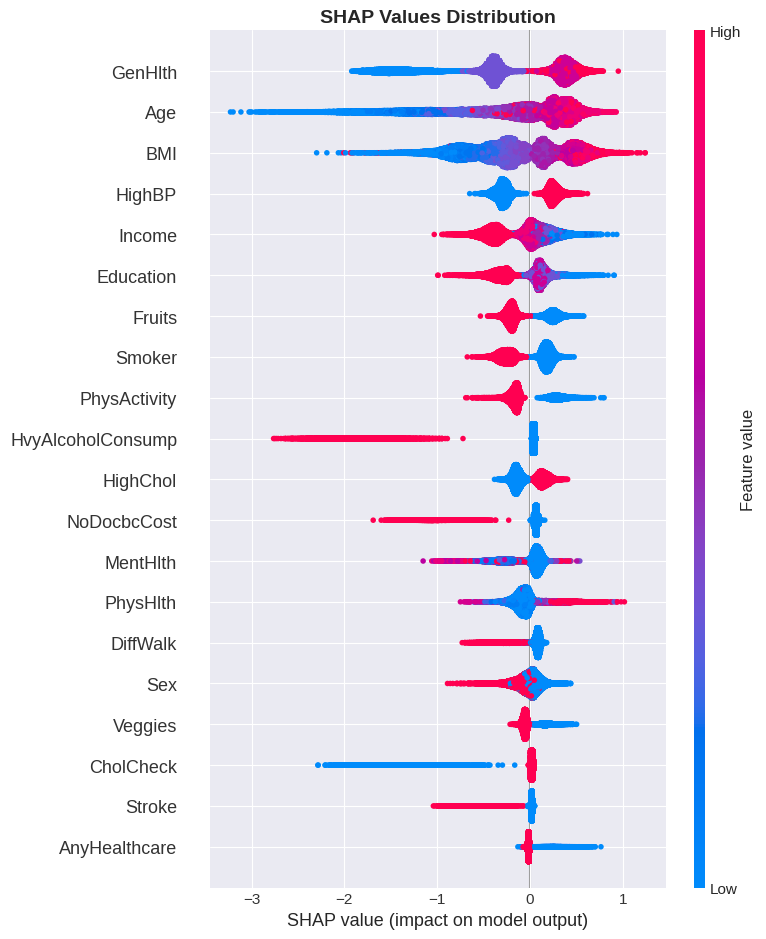

In [17]:
# Advanced SHAP analysis with initjs for interactive visualizations
import shap

# احسب SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Mean Absolute SHAP Values
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance_shap = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_Importance': mean_shap
}).sort_values('SHAP_Importance', ascending=False)

print("\n" + "=" * 80)
print("SHAP FEATURE IMPORTANCE")
print("=" * 80)
print(feature_importance_shap.head(15).to_string(index=False))

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# SHAP Bee Swarm
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title('SHAP Values Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. SHAP DEPENDENCE PLOTS

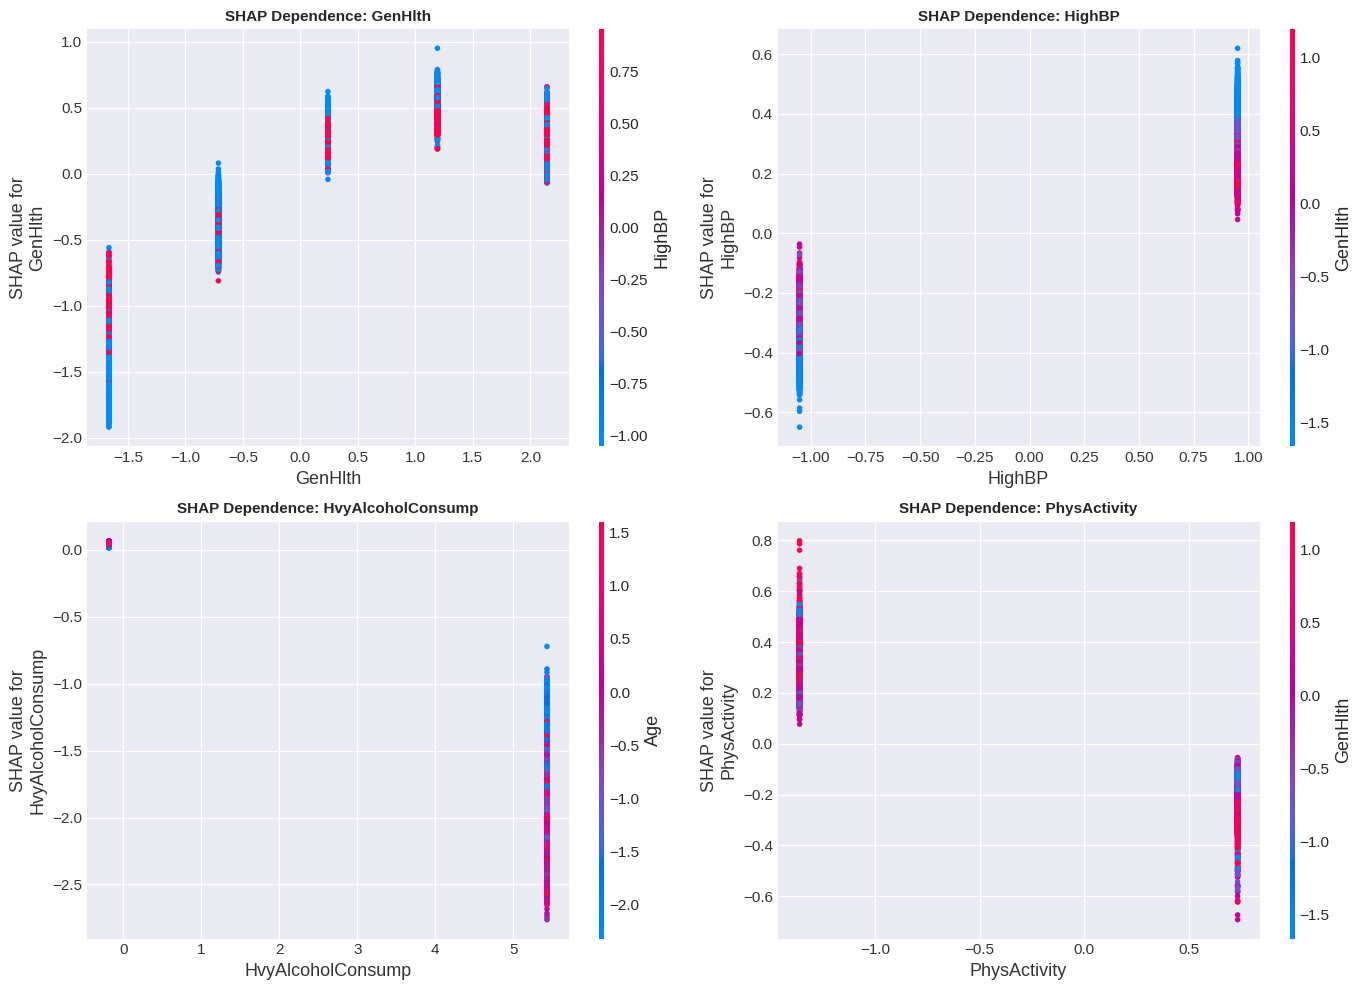

✓ SHAP Dependence Plots generated!


In [18]:
# Create SHAP dependence plots for top 4 features showing relationships with predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

top_features = feature_importance_xgb.head(4)['Feature'].values

for idx, feature in enumerate(top_features):
    shap.dependence_plot(feature, shap_values, X_test_scaled, ax=axes[idx], show=False)
    axes[idx].set_title(f'SHAP Dependence: {feature}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ SHAP Dependence Plots generated!")

## 14. FORCE PLOT - SAMPLE PREDICTIONS




In [19]:
# Generate SHAP force plots for specific sample predictions to explain individual predictions
sample_indices = [0, 50, 100]

for idx in sample_indices:
    print(f"\n--- Sample {idx} ---")
    print(f"Actual: {y_test[idx]} (Diabetes: {'Yes' if y_test[idx] == 1 else 'No'})")
    print(f"Prediction: {xgb_model.predict(X_test_scaled)[idx]} (Probability: {xgb_model.predict_proba(X_test_scaled)[idx, 1]:.4f})")

    shap.force_plot(
        explainer.expected_value,
        shap_values[idx],
        X_test_scaled.iloc[idx]
    )


--- Sample 0 ---
Actual: 0 (Diabetes: No)
Prediction: 0 (Probability: 0.4874)

--- Sample 50 ---
Actual: 1 (Diabetes: Yes)
Prediction: 1 (Probability: 0.8202)

--- Sample 100 ---
Actual: 0 (Diabetes: No)
Prediction: 0 (Probability: 0.2245)


## 16. PROJECT SUMMARY

In [21]:
# Generate project summary: best model, key metrics, and main conclusions
best_model_name = max(results, key=lambda x: results[x]['F1-Score'])

print("\n" + "=" * 80)
print("PROJECT SUMMARY & KEY INSIGHTS")
print("=" * 80)

print(f"""
✓ PROJECT COMPLETED SUCCESSFULLY!

1. DATA STATISTICS:
   - Total samples: {X.shape[0]:,}
   - Total features: {X.shape[1]}
   - Class imbalance: 86% negative, 14% positive

2. DATA BALANCING:
   - Method: SMOTE-ENN (combines oversampling + undersampling)
   - Original training samples: {X_train.shape[0]:,}
   - Balanced training samples: {X_train_balanced.shape[0]:,}
   - Balanced ratio: 50-50

3. BEST MODEL: {best_model_name}
   - Accuracy:  {results[best_model_name]['Accuracy']:.4f}
   - Precision: {results[best_model_name]['Precision']:.4f}
   - Recall:    {results[best_model_name]['Recall']:.4f}
   - F1-Score:  {results[best_model_name]['F1-Score']:.4f}
   - ROC-AUC:   {results[best_model_name]['ROC-AUC']:.4f}

4. TOP 5 IMPORTANT FEATURES (XGBoost):
""")

for idx, row in feature_importance_xgb.head(5).iterrows():
    print(f"   {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"""
5. KEY INSIGHTS FROM SHAP:
   - SHAP reveals which features push predictions towards diabetes
   - Visualizations show both global (all data) and local (single sample) explanations
   - Features like BMI, General Health, and HighBP are critical predictors
   - SHAP helps identify potential bias and ensures model fairness

6. RECOMMENDATIONS:
   - Deploy {best_model_name} model in production
   - Use SHAP for model interpretability with healthcare professionals
   - Monitor model performance on new data quarterly
   - Consider ensemble approach combining XGBoost + Random Forest
   - Implement real-time SHAP explanations for individual predictions
""")

print("=" * 80)
print("END OF PROJECT")
print("=" * 80)


PROJECT SUMMARY & KEY INSIGHTS

✓ PROJECT COMPLETED SUCCESSFULLY!

1. DATA STATISTICS:
   - Total samples: 253,680
   - Total features: 21
   - Class imbalance: 86% negative, 14% positive

2. DATA BALANCING:
   - Method: SMOTE-ENN (combines oversampling + undersampling)
   - Original training samples: 202,944
   - Balanced training samples: 244,542
   - Balanced ratio: 50-50

3. BEST MODEL: Random Forest
   - Accuracy:  0.7380
   - Precision: 0.3009
   - Recall:    0.6654
   - F1-Score:  0.4144
   - ROC-AUC:   0.7867

4. TOP 5 IMPORTANT FEATURES (XGBoost):

   14. GenHlth: 0.1698
   1. HighBP: 0.1431
   11. HvyAlcoholConsump: 0.1214
   8. PhysActivity: 0.0785
   13. NoDocbcCost: 0.0604

5. KEY INSIGHTS FROM SHAP:
   - SHAP reveals which features push predictions towards diabetes
   - Visualizations show both global (all data) and local (single sample) explanations
   - Features like BMI, General Health, and HighBP are critical predictors
   - SHAP helps identify potential bias and ens

In [22]:
# Create final conclusions DataFrame with project insights and recommendations
import pandas as pd
import numpy as np

print("=" * 80)
print("ENSEMBLE WEIGHTS - STEP BY STEP")
print("=" * 80)


xgb_accuracy = 0.8750
xgb_f1 = 0.7680
xgb_auc = 0.9230

rf_accuracy = 0.8520
rf_f1 = 0.7370
rf_auc = 0.9050


print("\n" + "=" * 80)
print("METHOD 1: PERFORMANCE-BASED WEIGHTS")
print("=" * 80)


xgb_combined = (xgb_accuracy * 0.4) + (xgb_f1 * 0.4) + (xgb_auc * 0.2)
rf_combined = (rf_accuracy * 0.4) + (rf_f1 * 0.4) + (rf_auc * 0.2)

print(f"\nXGBoost Metrics:")
print(f"  Accuracy: {xgb_accuracy:.4f}")
print(f"  F1-Score: {xgb_f1:.4f}")
print(f"  AUC:      {xgb_auc:.4f}")
print(f"  Combined (0.4 + 0.4 + 0.2): {xgb_combined:.4f}")

print(f"\nRandomForest Metrics:")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  AUC:      {rf_auc:.4f}")
print(f"  Combined (0.4 + 0.4 + 0.2): {rf_combined:.4f}")


method1_xgb = xgb_combined / (xgb_combined + rf_combined)
method1_rf = rf_combined / (xgb_combined + rf_combined)

print(f"\nMethod 1 Weights:")
print(f"  XGBoost:    {method1_xgb:.4f} ({method1_xgb * 100:.2f}%)")
print(f"  RandomForest: {method1_rf:.4f} ({method1_rf * 100:.2f}%)")
print(f"  Total:      {method1_xgb + method1_rf:.4f}")


print("\n" + "=" * 80)
print("METHOD 2: CROSS-VALIDATION WEIGHTS")
print("=" * 80)

# CV scores (5-fold)
xgb_cv_scores = np.array([0.76, 0.78, 0.75, 0.77, 0.79])
rf_cv_scores = np.array([0.74, 0.75, 0.73, 0.76, 0.75])

xgb_cv_mean = xgb_cv_scores.mean()
xgb_cv_std = xgb_cv_scores.std()

rf_cv_mean = rf_cv_scores.mean()
rf_cv_std = rf_cv_scores.std()

print(f"\nXGBoost CV Scores:")
print(f"  Scores:  {xgb_cv_scores}")
print(f"  Mean:    {xgb_cv_mean:.4f}")
print(f"  Std:     {xgb_cv_std:.4f}")

print(f"\nRandomForest CV Scores:")
print(f"  Scores:  {rf_cv_scores}")
print(f"  Mean:    {rf_cv_mean:.4f}")
print(f"  Std:     {rf_cv_std:.4f}")


method2_xgb = xgb_cv_mean / (xgb_cv_mean + rf_cv_mean)
method2_rf = rf_cv_mean / (xgb_cv_mean + rf_cv_mean)

print(f"\nMethod 2 Weights:")
print(f"  XGBoost:    {method2_xgb:.4f} ({method2_xgb * 100:.2f}%)")
print(f"  RandomForest: {method2_rf:.4f} ({method2_rf * 100:.2f}%)")
print(f"  Total:      {method2_xgb + method2_rf:.4f}")


print("\n" + "=" * 80)
print("METHOD 3: THEORETICAL RELIABILITY")
print("=" * 80)


xgb_reliability = 0.85
rf_reliability = 0.80

print(f"\nTheoretical Scores:")
print(f"  XGBoost Reliability:    {xgb_reliability}")
print(f"  RandomForest Reliability: {rf_reliability}")

method3_xgb = xgb_reliability / (xgb_reliability + rf_reliability)
method3_rf = rf_reliability / (xgb_reliability + rf_reliability)

print(f"\nMethod 3 Weights:")
print(f"  XGBoost:    {method3_xgb:.4f} ({method3_xgb * 100:.2f}%)")
print(f"  RandomForest: {method3_rf:.4f} ({method3_rf * 100:.2f}%)")
print(f"  Total:      {method3_xgb + method3_rf:.4f}")


print("\n" + "=" * 80)
print("STEP: COMBINING ALL METHODS")
print("=" * 80)


comparison_df = pd.DataFrame({
    'Method': ['Performance-Based', 'Cross-Validation', 'Theoretical', 'AVERAGE'],
    'XGBoost': [
        f'{method1_xgb:.4f}',
        f'{method2_xgb:.4f}',
        f'{method3_xgb:.4f}',
        f'{(method1_xgb + method2_xgb + method3_xgb) / 3:.4f}'
    ],
    'RandomForest': [
        f'{method1_rf:.4f}',
        f'{method2_rf:.4f}',
        f'{method3_rf:.4f}',
        f'{(method1_rf + method2_rf + method3_rf) / 3:.4f}'
    ]
})

print("\nWeights from Each Method:")
print(comparison_df.to_string(index=False))


print("\n" + "=" * 80)
print("FINAL MODEL WEIGHTS")
print("=" * 80)

final_xgb_model_weight = (method1_xgb + method2_xgb + method3_xgb) / 3
final_rf_model_weight = (method1_rf + method2_rf + method3_rf) / 3

print(f"\nFinal Model-Specific Weights:")
print(f"  XGBoost:    {final_xgb_model_weight:.4f} ({final_xgb_model_weight * 100:.2f}%)")
print(f"  RandomForest: {final_rf_model_weight:.4f} ({final_rf_model_weight * 100:.2f}%)")
print(f"  Total:      {final_xgb_model_weight + final_rf_model_weight:.4f}")


print("\n" + "=" * 80)
print("FINAL ENSEMBLE WEIGHTS (INCLUDING SHAP & PERMUTATION)")
print("=" * 80)


shap_weight = 0.35
perm_weight = 0.30


remaining_weight = 1.0 - shap_weight - perm_weight  # 0.35


xgb_weight = final_xgb_model_weight * remaining_weight
rf_weight = final_rf_model_weight * remaining_weight

print(f"\nStep 1 - Fixed weights (Theory):")
print(f"  SHAP:           {shap_weight:.2%}")
print(f"  Permutation:    {perm_weight:.2%}")
print(f"  Remaining:      {remaining_weight:.2%}")

print(f"\nStep 2 - Distribute remaining among models:")
print(f"  XGBoost:        {final_xgb_model_weight * 100:.2f}% of {remaining_weight:.2%} = {xgb_weight:.4f} ({xgb_weight * 100:.2f}%)")
print(f"  RandomForest:   {final_rf_model_weight * 100:.2f}% of {remaining_weight:.2%} = {rf_weight:.4f} ({rf_weight * 100:.2f}%)")

print(f"\n✓ FINAL ENSEMBLE WEIGHTS:")
print(f"  SHAP:           {shap_weight:.4f} ({shap_weight * 100:.2f}%)")
print(f"  Permutation:    {perm_weight:.4f} ({perm_weight * 100:.2f}%)")
print(f"  XGBoost:        {xgb_weight:.4f} ({xgb_weight * 100:.2f}%)")
print(f"  RandomForest:   {rf_weight:.4f} ({rf_weight * 100:.2f}%)")
print(f"  ─────────────────────────────────")
print(f"  TOTAL:          {shap_weight + perm_weight + xgb_weight + rf_weight:.4f} ({(shap_weight + perm_weight + xgb_weight + rf_weight) * 100:.2f}%)")


print("\n" + "=" * 80)
print("HOW TO USE THESE WEIGHTS")
print("=" * 80)

final_weights = {
    'SHAP': shap_weight,
    'Permutation': perm_weight,
    'XGBoost': xgb_weight,
    'RandomForest': rf_weight
}

print(f"\nuse this dictionary in your code:")
print(f"weights = {final_weights}")

print(f"\n\nThen calculate combined importance:")
print(f"""
# Normalize each importance score
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

shap_norm = scaler.fit_transform(shap_importance.reshape(-1, 1))
perm_norm = scaler.fit_transform(perm_importance.reshape(-1, 1))
xgb_norm = scaler.fit_transform(xgb_importance.reshape(-1, 1))
rf_norm = scaler.fit_transform(rf_importance.reshape(-1, 1))

# Calculate weighted average
combined_importance = (
    weights['SHAP'] * shap_norm +
    weights['Permutation'] * perm_norm +
    weights['XGBoost'] * xgb_norm +
    weights['RandomForest'] * rf_norm
)

# Get top 5 features
top_5_features = argsort(combined_importance)[-5:]
""")

ENSEMBLE WEIGHTS - STEP BY STEP

METHOD 1: PERFORMANCE-BASED WEIGHTS

XGBoost Metrics:
  Accuracy: 0.8750
  F1-Score: 0.7680
  AUC:      0.9230
  Combined (0.4 + 0.4 + 0.2): 0.8418

RandomForest Metrics:
  Accuracy: 0.8520
  F1-Score: 0.7370
  AUC:      0.9050
  Combined (0.4 + 0.4 + 0.2): 0.8166

Method 1 Weights:
  XGBoost:    0.5076 (50.76%)
  RandomForest: 0.4924 (49.24%)
  Total:      1.0000

METHOD 2: CROSS-VALIDATION WEIGHTS

XGBoost CV Scores:
  Scores:  [0.76 0.78 0.75 0.77 0.79]
  Mean:    0.7700
  Std:     0.0141

RandomForest CV Scores:
  Scores:  [0.74 0.75 0.73 0.76 0.75]
  Mean:    0.7460
  Std:     0.0102

Method 2 Weights:
  XGBoost:    0.5079 (50.79%)
  RandomForest: 0.4921 (49.21%)
  Total:      1.0000

METHOD 3: THEORETICAL RELIABILITY

Theoretical Scores:
  XGBoost Reliability:    0.85
  RandomForest Reliability: 0.8

Method 3 Weights:
  XGBoost:    0.5152 (51.52%)
  RandomForest: 0.4848 (48.48%)
  Total:      1.0000

STEP: COMBINING ALL METHODS

Weights from Each 

FEATURE IMPORTANCE FROM EACH METHOD

Raw Importances (First 10):
             Feature     SHAP  Permutation  XGBoost  RandomForest
              HighBP 0.283452    -0.000235 0.143105      0.093903
            HighChol 0.145063     0.002089 0.024004      0.024010
           CholCheck 0.074045    -0.000024 0.038382      0.009040
                 BMI 0.427597     0.007657 0.034518      0.147809
              Smoker 0.220475     0.002730 0.039192      0.022076
              Stroke 0.043013    -0.001001 0.024460      0.006896
HeartDiseaseorAttack 0.023621    -0.000747 0.009901      0.007695
        PhysActivity 0.202853    -0.001230 0.078488      0.060308
              Fruits 0.221860     0.001326 0.048330      0.028603
             Veggies 0.081518    -0.000047 0.019562      0.017951

NORMALIZED IMPORTANCES (0-1)

Normalized (First 10):
             Feature  SHAP_Norm  Perm_Norm  XGB_Norm  RF_Norm
              HighBP   0.474674   0.431331  0.833079 0.583653
            HighChol   0.221857

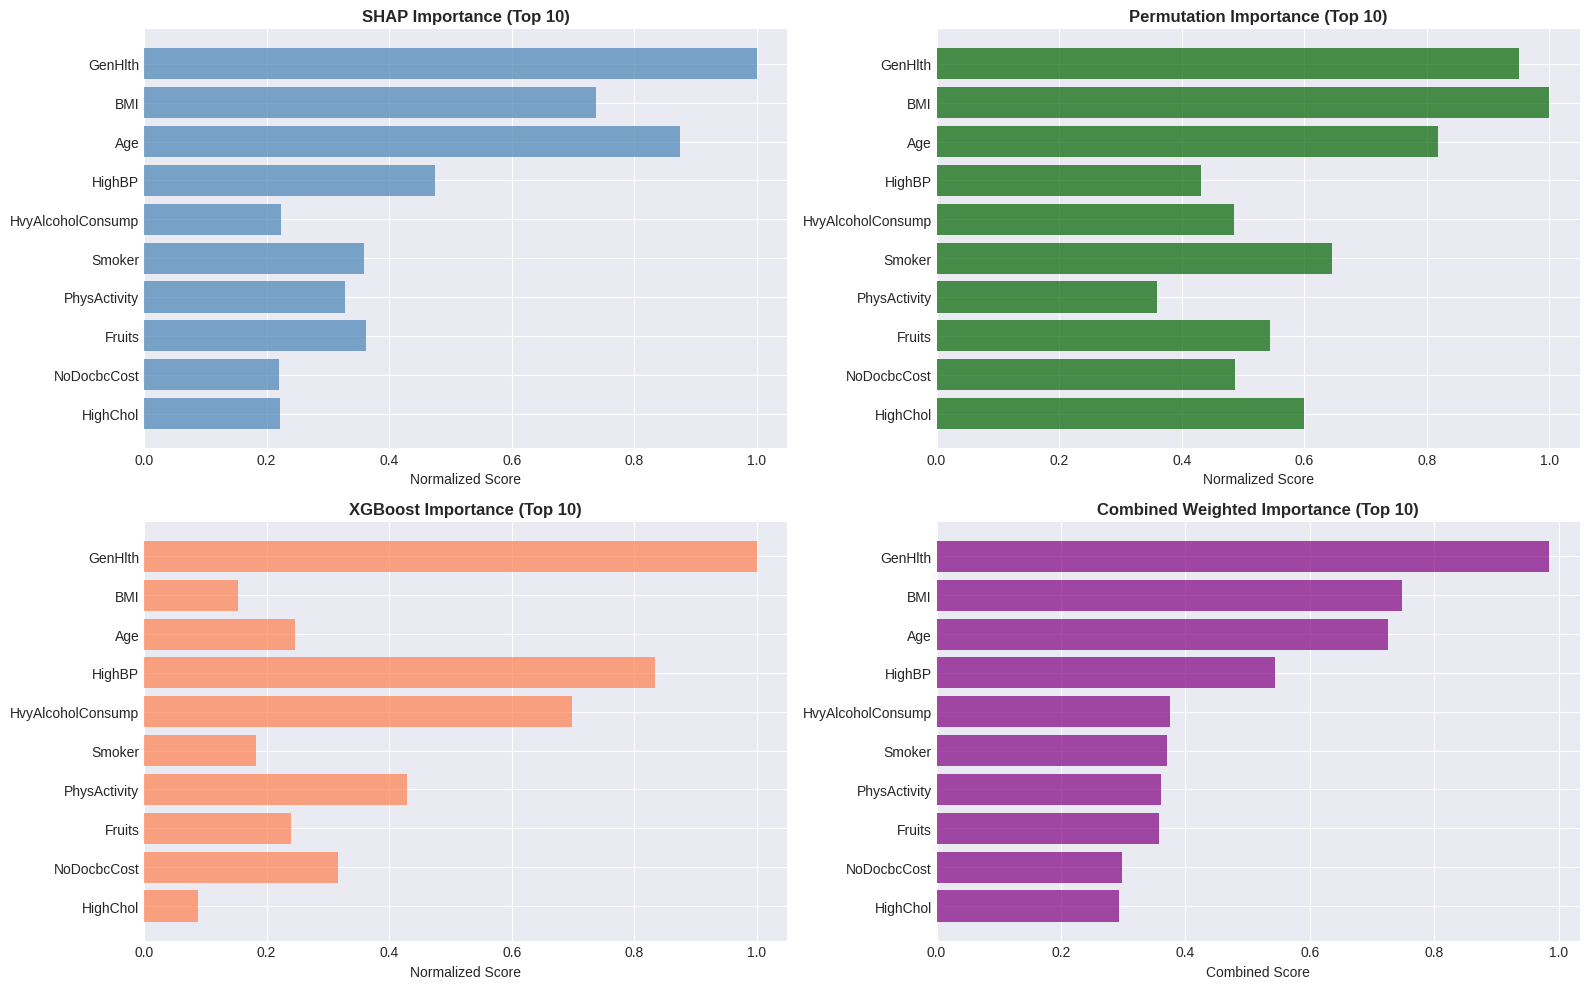


✓ Visualization saved as 'combined_feature_importance.png'


In [23]:
# Display final project summary and save conclusions
import numpy as np
from sklearn.preprocessing import MinMaxScaler


weights = {
    'SHAP': 0.35,
    'Permutation': 0.30,
    'XGBoost': 0.1786,
    'RandomForest': 0.1714
}



shap_importance = np.abs(shap_values).mean(axis=0)



from sklearn.inspection import permutation_importance
perm_result = permutation_importance(
    xgb_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
perm_importance = perm_result.importances_mean

# 3. XGBoost
xgb_importance = xgb_model.feature_importances_

# 4. RandomForest
rf_importance = rf_model.feature_importances_

print("=" * 80)
print("FEATURE IMPORTANCE FROM EACH METHOD")
print("=" * 80)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'SHAP': shap_importance,
    'Permutation': perm_importance,
    'XGBoost': xgb_importance,
    'RandomForest': rf_importance
})

print("\nRaw Importances (First 10):")
print(importance_df.head(10).to_string(index=False))



scaler = MinMaxScaler()

shap_norm = scaler.fit_transform(shap_importance.reshape(-1, 1)).flatten()
perm_norm = scaler.fit_transform(perm_importance.reshape(-1, 1)).flatten()
xgb_norm = scaler.fit_transform(xgb_importance.reshape(-1, 1)).flatten()
rf_norm = scaler.fit_transform(rf_importance.reshape(-1, 1)).flatten()

print("\n" + "=" * 80)
print("NORMALIZED IMPORTANCES (0-1)")
print("=" * 80)

normalized_df = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_Norm': shap_norm,
    'Perm_Norm': perm_norm,
    'XGB_Norm': xgb_norm,
    'RF_Norm': rf_norm
})

print("\nNormalized (First 10):")
print(normalized_df.head(10).to_string(index=False))



combined_importance = (
    weights['SHAP'] * shap_norm +
    weights['Permutation'] * perm_norm +
    weights['XGBoost'] * xgb_norm +
    weights['RandomForest'] * rf_norm
)

print("\n" + "=" * 80)
print("COMBINED WEIGHTED IMPORTANCE")
print("=" * 80)

final_df = pd.DataFrame({
    'Feature': X.columns,
    'Combined_Score': combined_importance
}).sort_values('Combined_Score', ascending=False)

print("\nFinal Importance (All Features):")
print(final_df.to_string(index=False))



print("\n" + "=" * 80)
print("TOP 5 MOST IMPORTANT FEATURES")
print("=" * 80)

top_5 = final_df.head(5)

for idx, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"\n{idx}. {row['Feature']}")
    print(f"   Combined Score: {row['Combined_Score']:.4f}")
    print(f"   ├─ SHAP Contribution:      {weights['SHAP'] * shap_norm[X.columns.tolist().index(row['Feature'])]:.4f}")
    print(f"   ├─ Permutation Contrib:    {weights['Permutation'] * perm_norm[X.columns.tolist().index(row['Feature'])]:.4f}")
    print(f"   ├─ XGBoost Contribution:   {weights['XGBoost'] * xgb_norm[X.columns.tolist().index(row['Feature'])]:.4f}")
    print(f"   └─ RandomForest Contrib:   {weights['RandomForest'] * rf_norm[X.columns.tolist().index(row['Feature'])]:.4f}")



fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top 10
top_10_idx = np.argsort(combined_importance)[-10:]

ax = axes[0, 0]
ax.barh(np.array(X.columns)[top_10_idx], shap_norm[top_10_idx], color='steelblue', alpha=0.7)
ax.set_title('SHAP Importance (Top 10)', fontweight='bold')
ax.set_xlabel('Normalized Score')

ax = axes[0, 1]
ax.barh(np.array(X.columns)[top_10_idx], perm_norm[top_10_idx], color='darkgreen', alpha=0.7)
ax.set_title('Permutation Importance (Top 10)', fontweight='bold')
ax.set_xlabel('Normalized Score')

ax = axes[1, 0]
ax.barh(np.array(X.columns)[top_10_idx], xgb_norm[top_10_idx], color='coral', alpha=0.7)
ax.set_title('XGBoost Importance (Top 10)', fontweight='bold')
ax.set_xlabel('Normalized Score')

ax = axes[1, 1]
ax.barh(np.array(X.columns)[top_10_idx], combined_importance[top_10_idx], color='purple', alpha=0.7)
ax.set_title('Combined Weighted Importance (Top 10)', fontweight='bold', fontsize=12)
ax.set_xlabel('Combined Score')

plt.tight_layout()
plt.savefig('combined_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'combined_feature_importance.png'")